## 1  Setup & Data Loading

In [1]:
import warnings, os
warnings.filterwarnings("ignore")
import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.ticker  as mticker
import seaborn            as sns
sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (12, 5)})
from sklearn.model_selection  import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing    import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.preprocessing    import OneHotEncoder
from sklearn.linear_model     import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble         import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics          import mean_absolute_error, mean_squared_error, r2_score
try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost not installed — skipping that model.")
from statsmodels.tsa.statespace.sarimax          import SARIMAX
from statsmodels.tsa.holtwinters                 import ExponentialSmoothing
from statsmodels.tsa.seasonal                    import seasonal_decompose
from statsmodels.tsa.stattools                   import adfuller

In [ ]:
# ── 1.1 Data Loading ─────────────────────────────────────────────────────────────
DATA_PATH = "tesla_deliveries_dataset_2015_2025.csv"
df_raw = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print(f"Shape : {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(8)


Shape : (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216


## 2  Preprocessing & Quality Checks

In [5]:
df = df_raw.copy()

# ── 2.1 Basic info ─────────────────────────────────────────────────────────────
print("=== dtypes ===")
print(df.dtypes)
print()

print("=== Missing values ===")
print(df.isnull().sum())
print()

print("=== Duplicates ===")
print(f"Duplicate rows: {df.duplicated().sum()}")


=== dtypes ===
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

=== Missing values ===
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

=== Duplicates ===
Duplicate rows: 0


In [7]:
# ── 2.2 Statistical summary ────────────────────────────────────────────────────
df.describe()


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


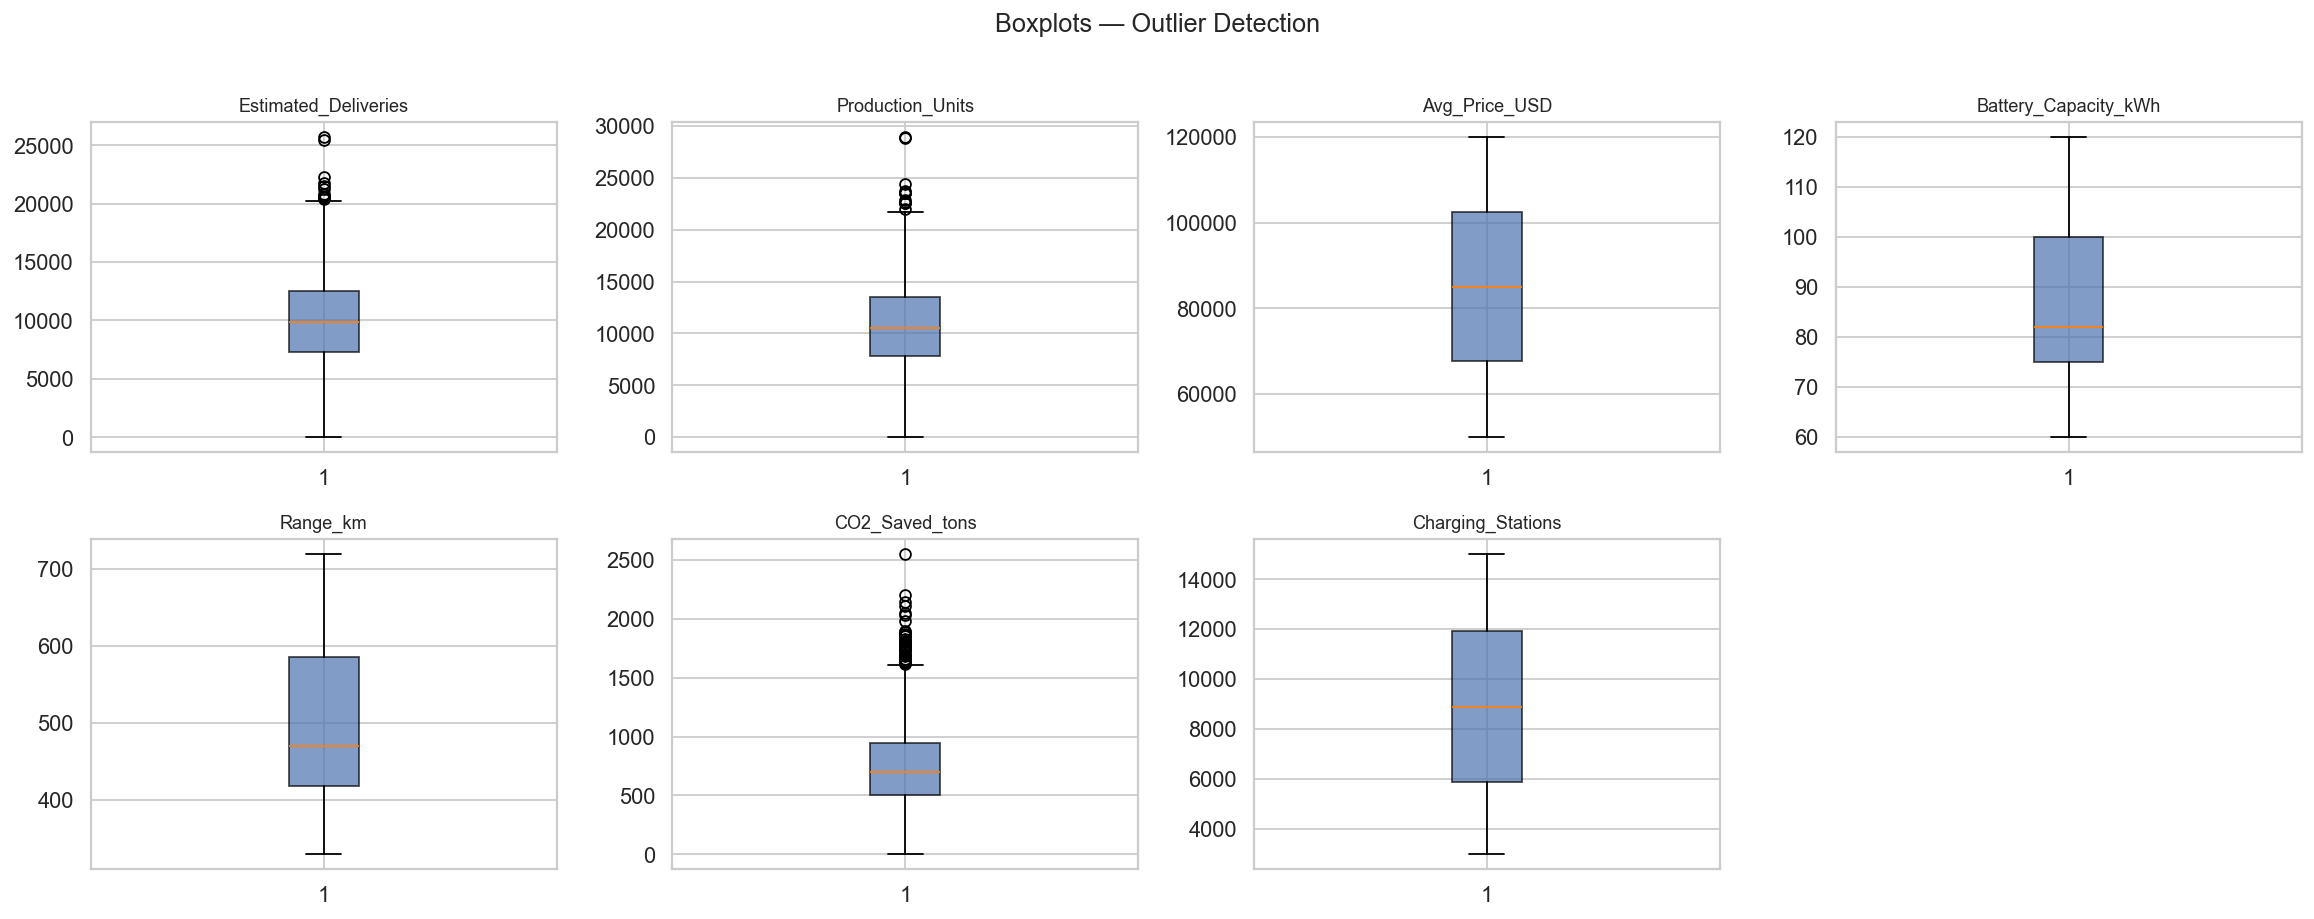

In [8]:
# ── 2.3 Date column & sorting ──────────────────────────────────────────────────
df["Date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))
df.sort_values("Date", inplace=True)
df.reset_index(drop=True, inplace=True)

# ── 2.4 Drop perfect duplicates ────────────────────────────────────────────────
df.drop_duplicates(inplace=True)

# ── 2.5 Outlier detection via IQR ──────────────────────────────────────────────
num_cols = ["Estimated_Deliveries", "Production_Units", "Avg_Price_USD",
            "Battery_Capacity_kWh", "Range_km", "CO2_Saved_tons", "Charging_Stations"]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#4C72B0", alpha=0.7))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
axes[-1].set_visible(False)
plt.suptitle("Boxplots — Outlier Detection", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [11]:
# ── 2.6 Clip extreme outliers (>3 std) ────────────────────────────────────────
for col in num_cols:
    mean, std = df[col].mean(), df[col].std()
    df[col] = df[col].clip(mean - 3*std, mean + 3*std)

print(df.shape)


(2640, 13)


## 3  Exploratory Data Analysis (EDA)

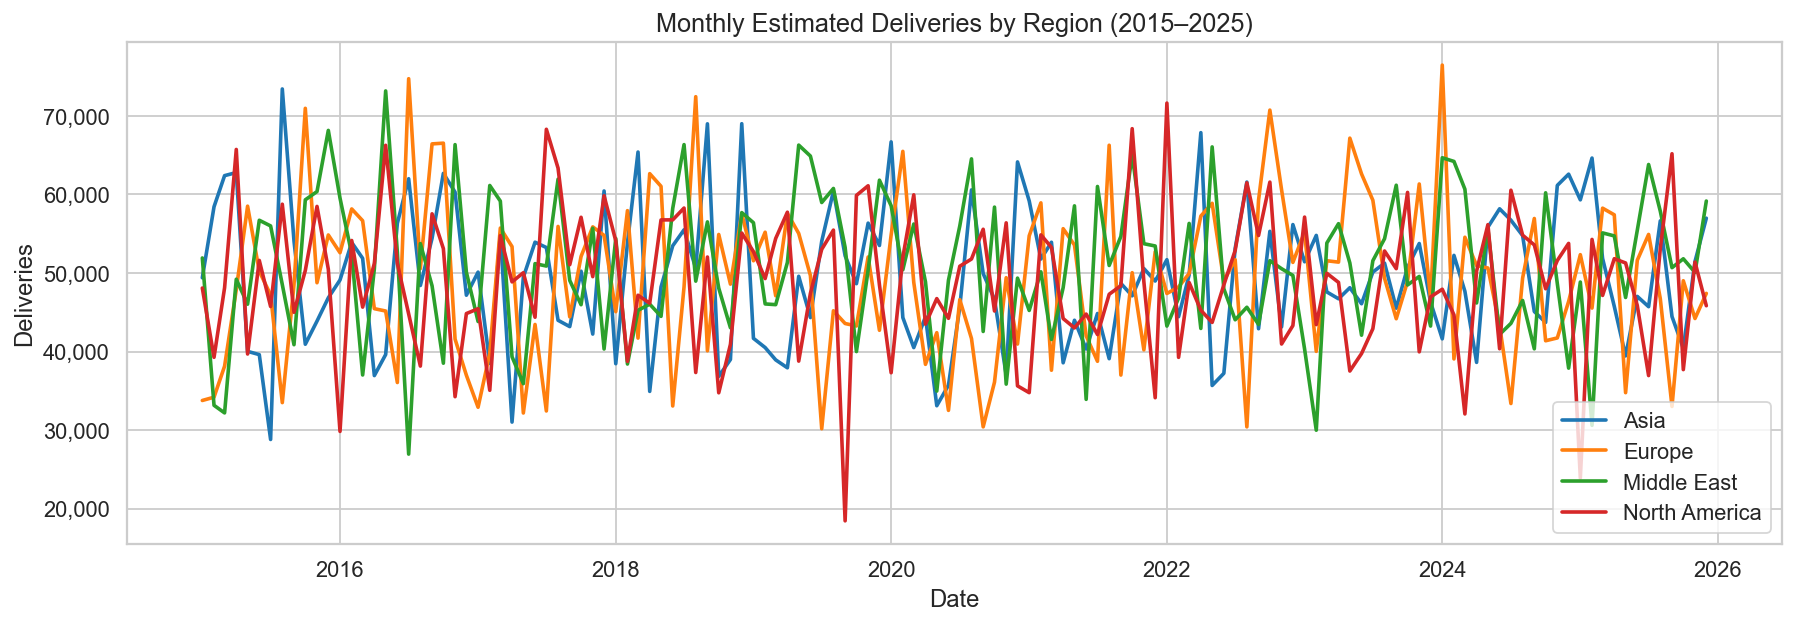

In [12]:
# ── 3.1 Deliveries over time (all regions) ─────────────────────────────────────
monthly = (
    df.groupby(["Date", "Region"])["Estimated_Deliveries"]
    .sum().reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
for region, grp in monthly.groupby("Region"):
    ax.plot(grp["Date"], grp["Estimated_Deliveries"], label=region, linewidth=2)
ax.set_title("Monthly Estimated Deliveries by Region (2015–2025)", fontsize=14)
ax.set_xlabel("Date"); ax.set_ylabel("Deliveries")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
ax.legend(); plt.tight_layout(); plt.show()


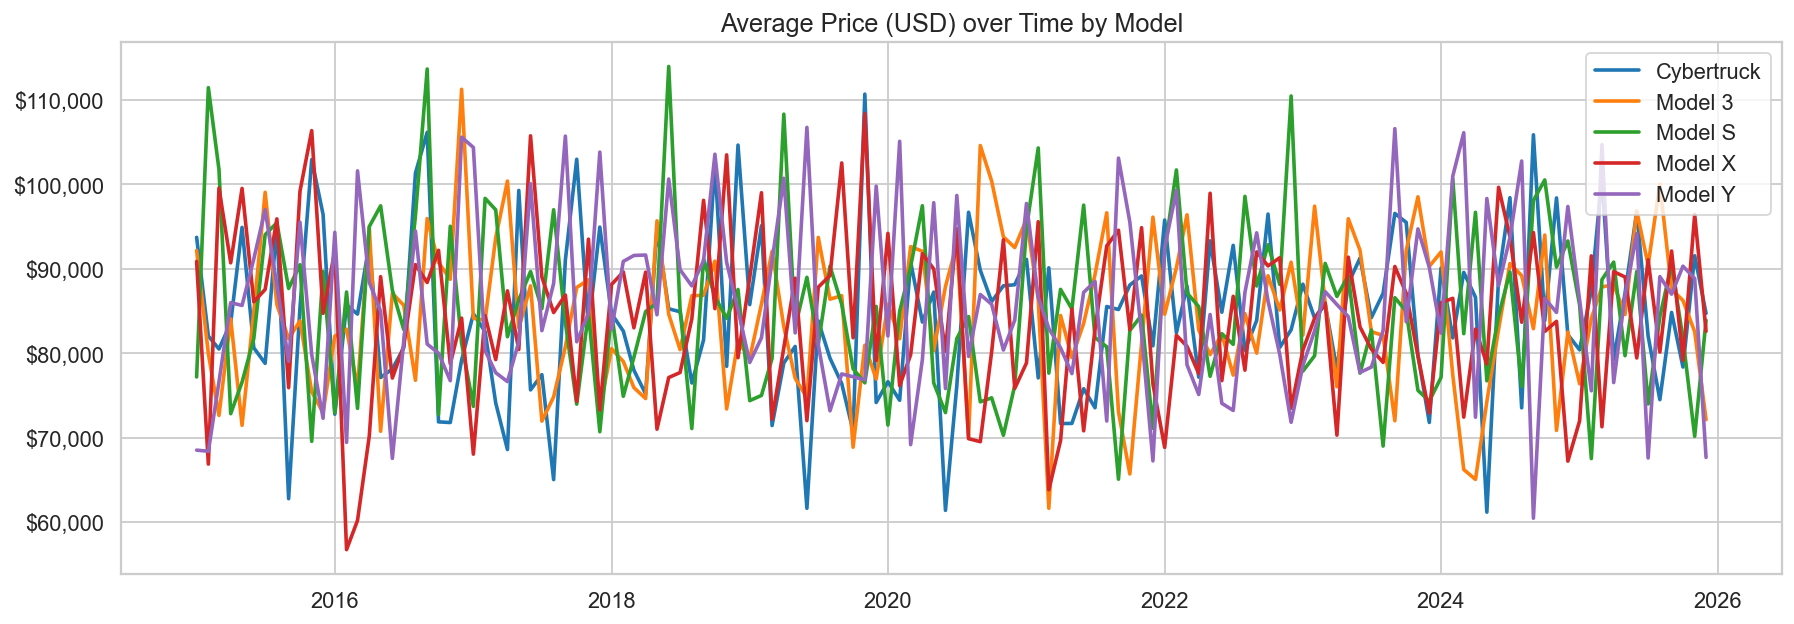

In [13]:
# ── 3.2 Average price over time by Model ──────────────────────────────────────
price_ts = df.groupby(["Date", "Model"])["Avg_Price_USD"].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for model, grp in price_ts.groupby("Model"):
    ax.plot(grp["Date"], grp["Avg_Price_USD"], label=model, linewidth=2)
ax.set_title("Average Price (USD) over Time by Model", fontsize=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${int(x):,}"))
ax.legend(); plt.tight_layout(); plt.show()


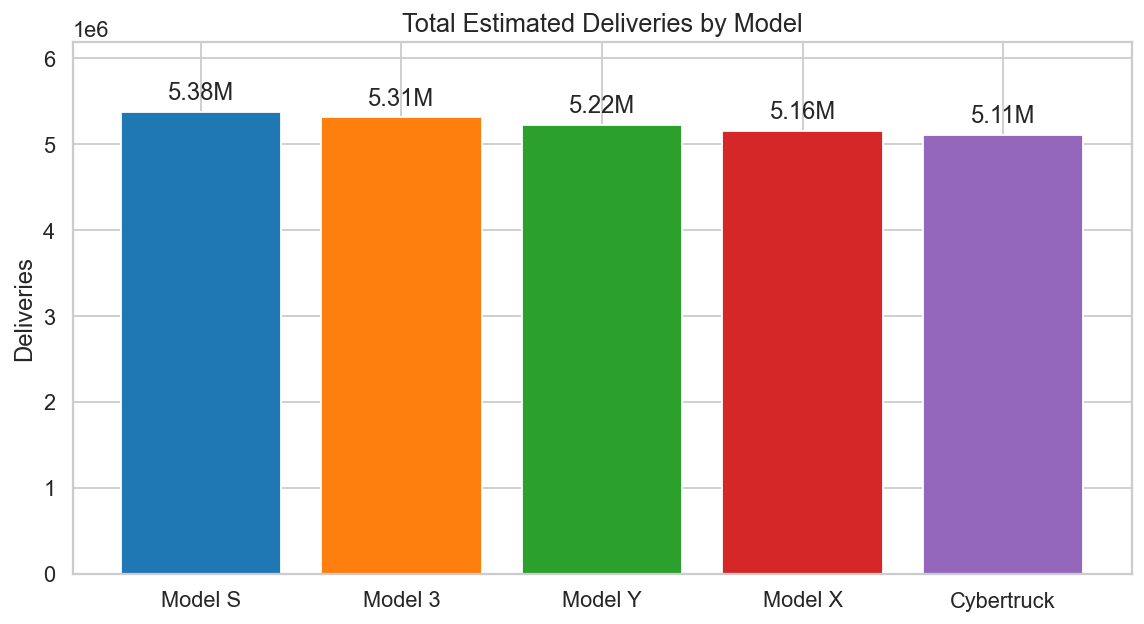

In [14]:
# ── 3.3 Deliveries by Model (bar) ─────────────────────────────────────────────
model_total = df.groupby("Model")["Estimated_Deliveries"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_total.index, model_total.values,
              color=sns.color_palette("tab10", len(model_total)))
ax.bar_label(bars, labels=[f"{v/1e6:.2f}M" for v in model_total.values], padding=4)
ax.set_title("Total Estimated Deliveries by Model", fontsize=14)
ax.set_ylabel("Deliveries"); ax.set_ylim(0, model_total.max()*1.15)
plt.tight_layout(); plt.show()


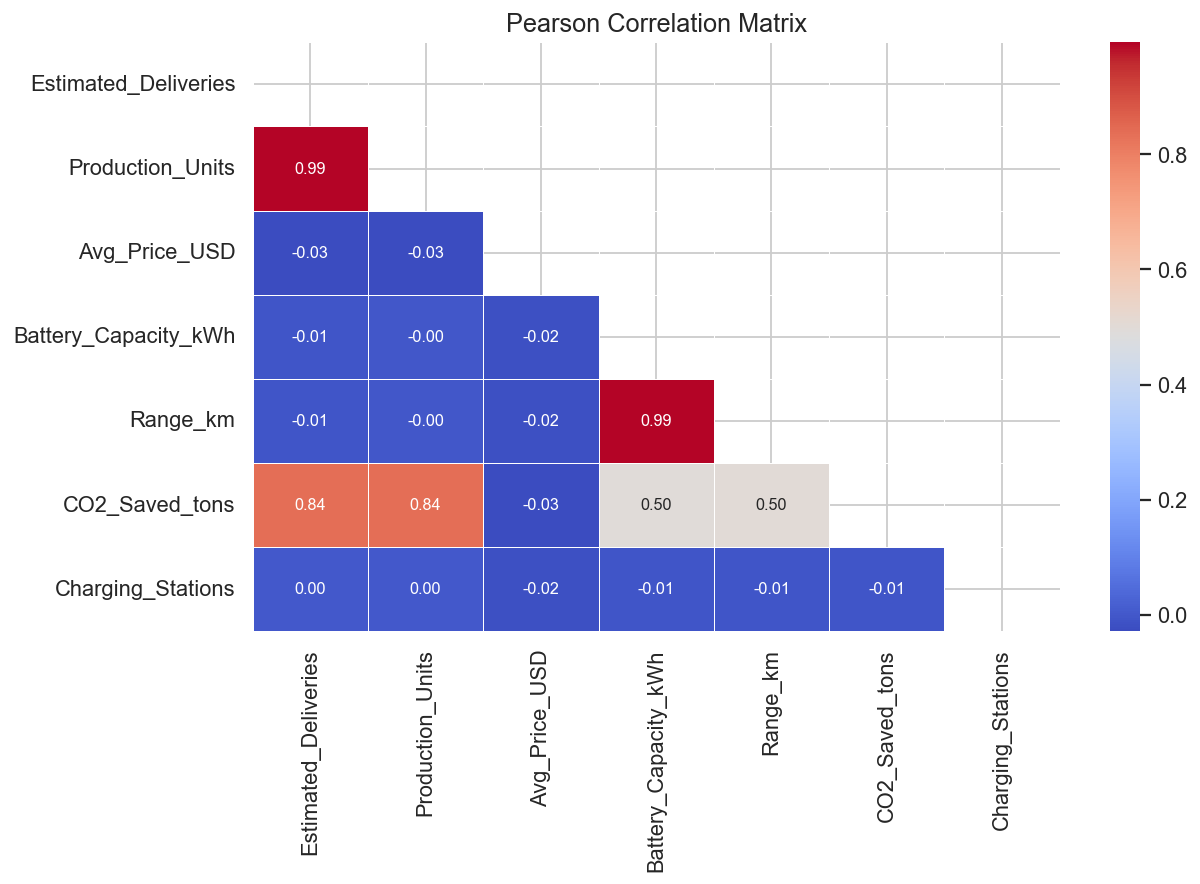

In [15]:
# ── 3.4 Correlation heatmap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Pearson Correlation Matrix", fontsize=14)
plt.tight_layout(); plt.show()


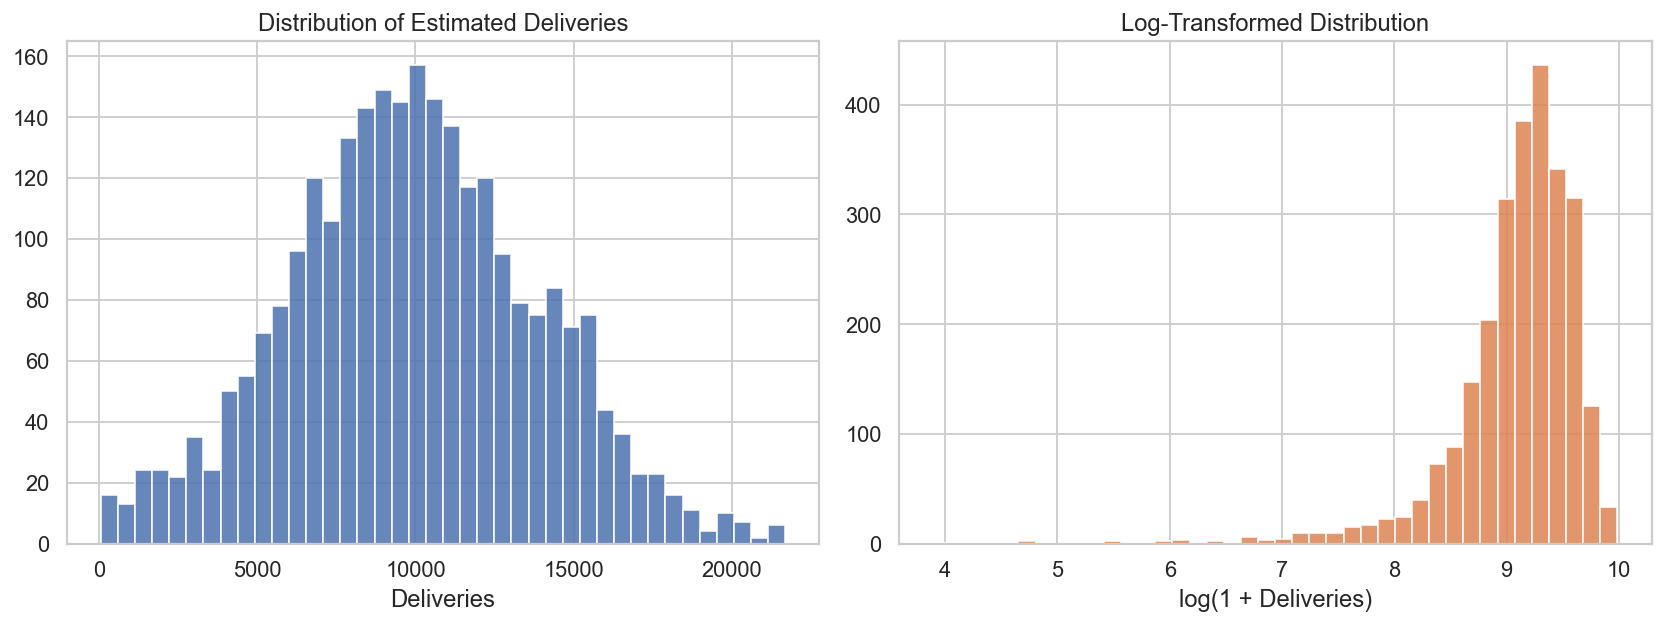

In [16]:
# ── 3.5 Delivery distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df["Estimated_Deliveries"], bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].set_title("Distribution of Estimated Deliveries")
axes[0].set_xlabel("Deliveries")

axes[1].hist(np.log1p(df["Estimated_Deliveries"]), bins=40,
             color="#DD8452", edgecolor="white", alpha=0.85)
axes[1].set_title("Log-Transformed Distribution")
axes[1].set_xlabel("log(1 + Deliveries)")
plt.tight_layout(); plt.show()


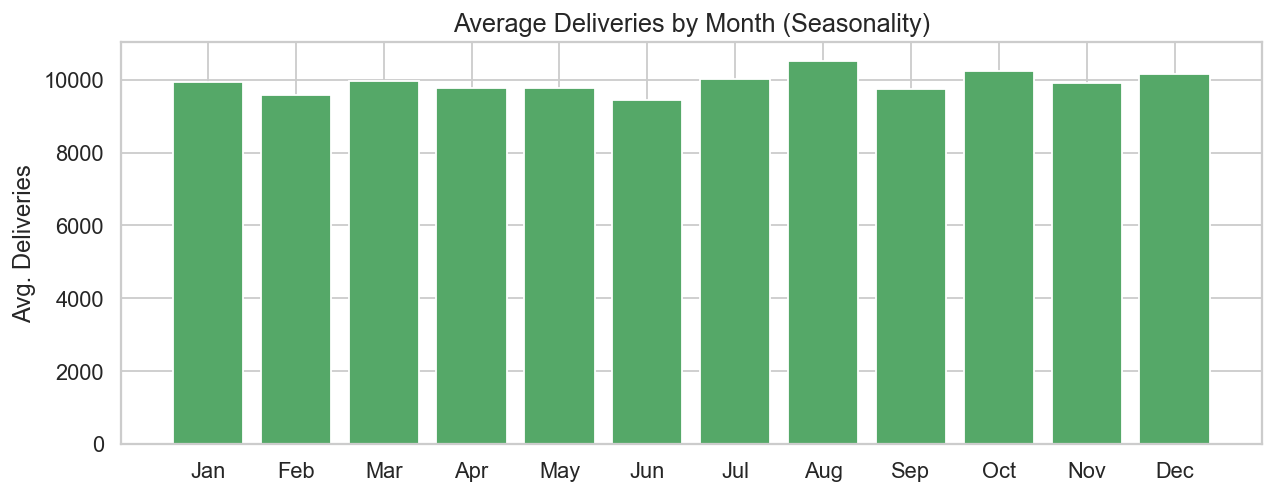

In [17]:
# ── 3.6 Seasonality: month vs avg deliveries ──────────────────────────────────
monthly_season = df.groupby("Month")["Estimated_Deliveries"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly_season.index, monthly_season.values, color="#55A868", edgecolor="white")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Average Deliveries by Month (Seasonality)", fontsize=14)
ax.set_ylabel("Avg. Deliveries")
plt.tight_layout(); plt.show()


## 4  Feature Engineering

In [19]:
fe = df.copy()

# ── 4.1 Time features ──────────────────────────────────────────────────────────
fe["Year_Num"]        = fe["Year"]
fe["Month_Sin"]       = np.sin(2 * np.pi * fe["Month"] / 12)
fe["Month_Cos"]       = np.cos(2 * np.pi * fe["Month"] / 12)
fe["Quarter"]         = fe["Month"].apply(lambda m: (m - 1) // 3 + 1)
fe["IsQ4"]            = (fe["Quarter"] == 4).astype(int)

# ── 4.2 Price-related features ─────────────────────────────────────────────────
fe["Log_Price"]       = np.log1p(fe["Avg_Price_USD"])
fe["Price_per_km"]    = fe["Avg_Price_USD"] / fe["Range_km"]

# ── 4.3 Production efficiency ──────────────────────────────────────────────────
fe["Delivery_Rate"]   = fe["Estimated_Deliveries"] / fe["Production_Units"].replace(0, np.nan)
fe["Delivery_Rate"]   = fe["Delivery_Rate"].fillna(fe["Delivery_Rate"].median())

# ── 4.4 Charging density ───────────────────────────────────────────────────────
fe["Stations_per_kWh"]= fe["Charging_Stations"] / fe["Battery_Capacity_kWh"]

# ── 4.5 Encode categoricals ────────────────────────────────────────────────────
fe = pd.get_dummies(fe, columns=["Region", "Model", "Source_Type"], drop_first=True)

# ── 4.6 Log-transform target ───────────────────────────────────────────────────
fe["Log_Deliveries"]  = np.log1p(fe["Estimated_Deliveries"])

print("Feature matrix shape:", fe.shape)
fe.head(3)


Feature matrix shape: (2640, 29)


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date,...,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter),Log_Deliveries
0,2015,1,12446.0,13885.0,55183.13,60,340,634.75,4390,2015-01-01,...,False,False,False,False,False,False,True,False,True,9.429235
1,2015,1,11446.0,12752.0,89289.40,100,588,1009.54,8925,2015-01-01,...,False,True,False,True,False,False,False,False,False,9.345483
2,2015,1,8803.0,9344.0,102888.58,60,336,443.67,3923,2015-01-01,...,False,True,False,False,False,False,False,True,False,9.082961


## 5  Regression Modelling

In [20]:
# ── 5.1 Define feature / target sets ──────────────────────────────────────────
DROP = ["Estimated_Deliveries", "Log_Deliveries", "Date",
        "Year", "Month", "CO2_Saved_tons"]
feature_cols = [c for c in fe.columns if c not in DROP]

X = fe[feature_cols].fillna(0).astype(float)
y = fe["Log_Deliveries"]          # predict log, invert at evaluation

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


Train: (2112, 23)  |  Test: (528, 23)


In [21]:
# ── 5.2 Baseline models ────────────────────────────────────────────────────────
def evaluate(name, model, X_tr, y_tr, X_te, y_te, scaled=True):
    model.fit(X_tr, y_tr)
    preds  = model.predict(X_te)
    # Invert log to get original scale metrics
    y_orig = np.expm1(y_te)
    p_orig = np.expm1(preds)
    mae    = mean_absolute_error(y_orig, p_orig)
    rmse   = np.sqrt(mean_squared_error(y_orig, p_orig))
    r2     = r2_score(y_orig, p_orig)
    cv     = cross_val_score(model, X_tr, y_tr, cv=5, scoring="r2").mean()
    print(f"{name:<30} MAE={mae:>10,.0f}  RMSE={rmse:>10,.0f}  R²={r2:.4f}  CV-R²={cv:.4f}")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "CV_R2": cv,
            "fitted": model, "preds": preds}

results = []
print(f"{'Model':<30} {'MAE':>15} {'RMSE':>15} {'R²':>8} {'CV-R²':>8}")
print("-"*75)

results.append(evaluate("Linear Regression",
    LinearRegression(), X_train_s, y_train, X_test_s, y_test))

results.append(evaluate("Ridge (α=1)",
    Ridge(alpha=1.0), X_train_s, y_train, X_test_s, y_test))

results.append(evaluate("Lasso (α=0.01)",
    Lasso(alpha=0.01, max_iter=5000), X_train_s, y_train, X_test_s, y_test))

results.append(evaluate("ElasticNet",
    ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000),
    X_train_s, y_train, X_test_s, y_test))

results.append(evaluate("Random Forest",
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test, scaled=False))

results.append(evaluate("Gradient Boosting",
    GradientBoostingRegressor(n_estimators=200, random_state=42),
    X_train, y_train, X_test, y_test, scaled=False))

if XGB_AVAILABLE:
    results.append(evaluate("XGBoost",
        XGBRegressor(n_estimators=200, random_state=42, verbosity=0, n_jobs=-1),
        X_train, y_train, X_test, y_test, scaled=False))


Model                                      MAE            RMSE       R²    CV-R²
---------------------------------------------------------------------------
Linear Regression              MAE=     1,211  RMSE=     1,909  R²=0.7568  CV-R²=0.8074
Ridge (α=1)                    MAE=     1,208  RMSE=     1,904  R²=0.7581  CV-R²=0.8074
Lasso (α=0.01)                 MAE=     1,133  RMSE=     1,777  R²=0.7892  CV-R²=0.8074
ElasticNet                     MAE=     1,147  RMSE=     1,797  R²=0.7845  CV-R²=0.8075
Random Forest                  MAE=        59  RMSE=       109  R²=0.9992  CV-R²=0.9968
Gradient Boosting              MAE=        62  RMSE=        80  R²=0.9996  CV-R²=0.9991
XGBoost                        MAE=        78  RMSE=       136  R²=0.9988  CV-R²=0.9912


In [22]:
# ── 5.3 Results table ─────────────────────────────────────────────────────────
res_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ("fitted","preds")}
                        for r in results])
res_df.sort_values("R2", ascending=False).style     .background_gradient(cmap="Greens", subset=["R2","CV_R2"])     .background_gradient(cmap="Reds_r", subset=["MAE","RMSE"])     .format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "R2": "{:.4f}", "CV_R2": "{:.4f}"})


,Model,MAE,RMSE,R2,CV_R2
5,Gradient Boosting,62,80,0.9996,0.9991
4,Random Forest,59,109,0.9992,0.9968
6,XGBoost,78,136,0.9988,0.9912
2,Lasso (α=0.01),"1,133","1,777",0.7892,0.8074
3,ElasticNet,"1,147","1,797",0.7845,0.8075
1,Ridge (α=1),"1,208","1,904",0.7581,0.8074
0,Linear Regression,"1,211","1,909",0.7568,0.8074


Best model: Gradient Boosting  (R² = 0.9996)


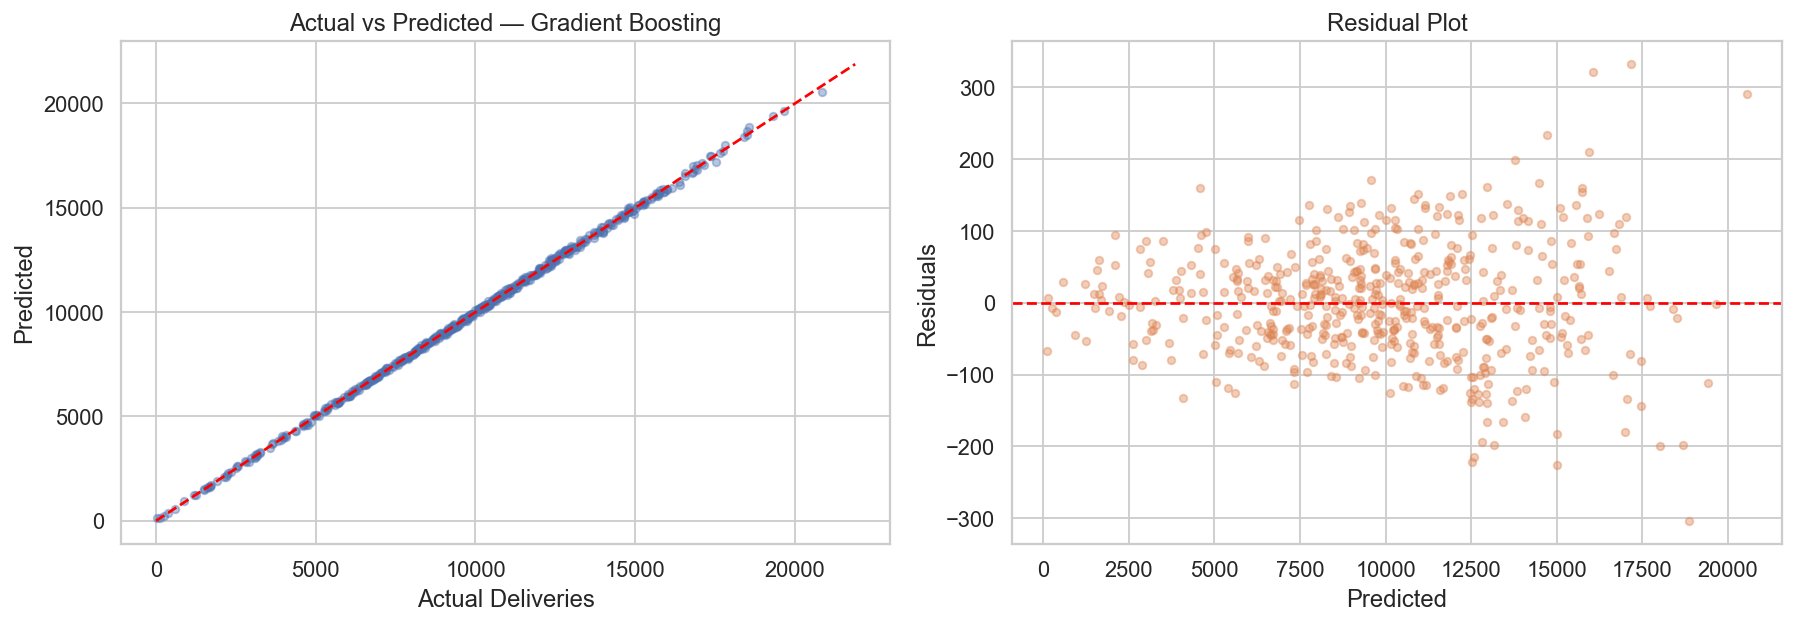

In [23]:
# ── 5.4 Actual vs Predicted — best model ──────────────────────────────────────
best = max(results, key=lambda r: r["R2"])
print(f"Best model: {best['Model']}  (R² = {best['R2']:.4f})")

y_orig  = np.expm1(y_test.values)
p_orig  = np.expm1(best["preds"])
lim     = max(y_orig.max(), p_orig.max()) * 1.05

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_orig, p_orig, alpha=0.4, s=18, color="#4C72B0")
axes[0].plot([0, lim], [0, lim], "r--", linewidth=1.5)
axes[0].set_xlabel("Actual Deliveries"); axes[0].set_ylabel("Predicted")
axes[0].set_title(f"Actual vs Predicted — {best['Model']}")

residuals = y_orig - p_orig
axes[1].scatter(p_orig, residuals, alpha=0.4, s=18, color="#DD8452")
axes[1].axhline(0, color="red", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot")
plt.tight_layout(); plt.show()


## 6  Hyperparameter Tuning

In [24]:
# ── 6.1 Random Forest — RandomizedSearchCV ────────────────────────────────────
from scipy.stats import randint, uniform

rf_param_dist = {
    "n_estimators":      randint(100, 500),
    "max_depth":         [None, 5, 10, 15, 20],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf":  randint(1, 10),
    "max_features":      ["sqrt", "log2", 0.5, 0.7],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=30, cv=5, scoring="r2",
    random_state=42, n_jobs=-1, verbose=0,
)
rf_search.fit(X_train, y_train)

print("Best RF params:")
for k, v in rf_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV R²: {rf_search.best_score_:.4f}")


Best RF params:
  max_depth: None
  max_features: 0.7
  min_samples_leaf: 2
  min_samples_split: 10
  n_estimators: 445
Best CV R²: 0.9898


In [25]:
# ── 6.2 Ridge — GridSearchCV ──────────────────────────────────────────────────
ridge_params = {"alpha": [0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]}
ridge_gs = GridSearchCV(Ridge(), ridge_params, cv=5, scoring="r2", n_jobs=-1)
ridge_gs.fit(X_train_s, y_train)

print(f"Best Ridge α : {ridge_gs.best_params_['alpha']}")
print(f"Best CV R²  : {ridge_gs.best_score_:.4f}")


Best Ridge α : 10
Best CV R²  : 0.8075


In [26]:
# ── 6.3 XGBoost — RandomizedSearchCV ─────────────────────────────────────────
if XGB_AVAILABLE:
    xgb_param_dist = {
        "n_estimators":   randint(100, 500),
        "max_depth":      randint(3, 10),
        "learning_rate":  uniform(0.01, 0.3),
        "subsample":      uniform(0.5, 0.5),
        "colsample_bytree": uniform(0.5, 0.5),
        "reg_alpha":      uniform(0, 1),
        "reg_lambda":     uniform(0.5, 2),
    }
    xgb_search = RandomizedSearchCV(
        XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
        param_distributions=xgb_param_dist,
        n_iter=30, cv=5, scoring="r2",
        random_state=42, n_jobs=-1, verbose=0,
    )
    xgb_search.fit(X_train, y_train)
    print("Best XGBoost params:")
    for k, v in xgb_search.best_params_.items():
        print(f"  {k}: {v}")
    print(f"Best CV R²: {xgb_search.best_score_:.4f}")


Best XGBoost params:
  colsample_bytree: 0.9574798377718904
  learning_rate: 0.2650115733369398
  max_depth: 6
  n_estimators: 132
  reg_alpha: 0.06355835028602363
  reg_lambda: 1.1219646434313244
  subsample: 0.6625916610133735
Best CV R²: 0.9921


In [27]:
# ── 6.4 Tuned model comparison ────────────────────────────────────────────────
def eval_model(name, model, X_te, y_te):
    preds  = model.predict(X_te)
    y_orig = np.expm1(y_te.values)
    p_orig = np.expm1(preds)
    return {
        "Model": name,
        "MAE":   mean_absolute_error(y_orig, p_orig),
        "RMSE":  np.sqrt(mean_squared_error(y_orig, p_orig)),
        "R2":    r2_score(y_orig, p_orig),
    }

tuned = [
    eval_model("Tuned Ridge",         ridge_gs.best_estimator_, X_test_s, y_test),
    eval_model("Tuned Random Forest",  rf_search.best_estimator_, X_test, y_test),
]
if XGB_AVAILABLE:
    tuned.append(eval_model("Tuned XGBoost", xgb_search.best_estimator_, X_test, y_test))

tuned_df = pd.DataFrame(tuned).sort_values("R2", ascending=False)
tuned_df.style     .background_gradient(cmap="Greens", subset=["R2"])     .background_gradient(cmap="Reds_r", subset=["MAE","RMSE"])     .format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "R2": "{:.4f}"})


,Model,MAE,RMSE,R2
2,Tuned XGBoost,93,160,0.9983
1,Tuned Random Forest,97,161,0.9983
0,Tuned Ridge,"1,190","1,867",0.7674


## 7  Model Evaluation & Feature Importance

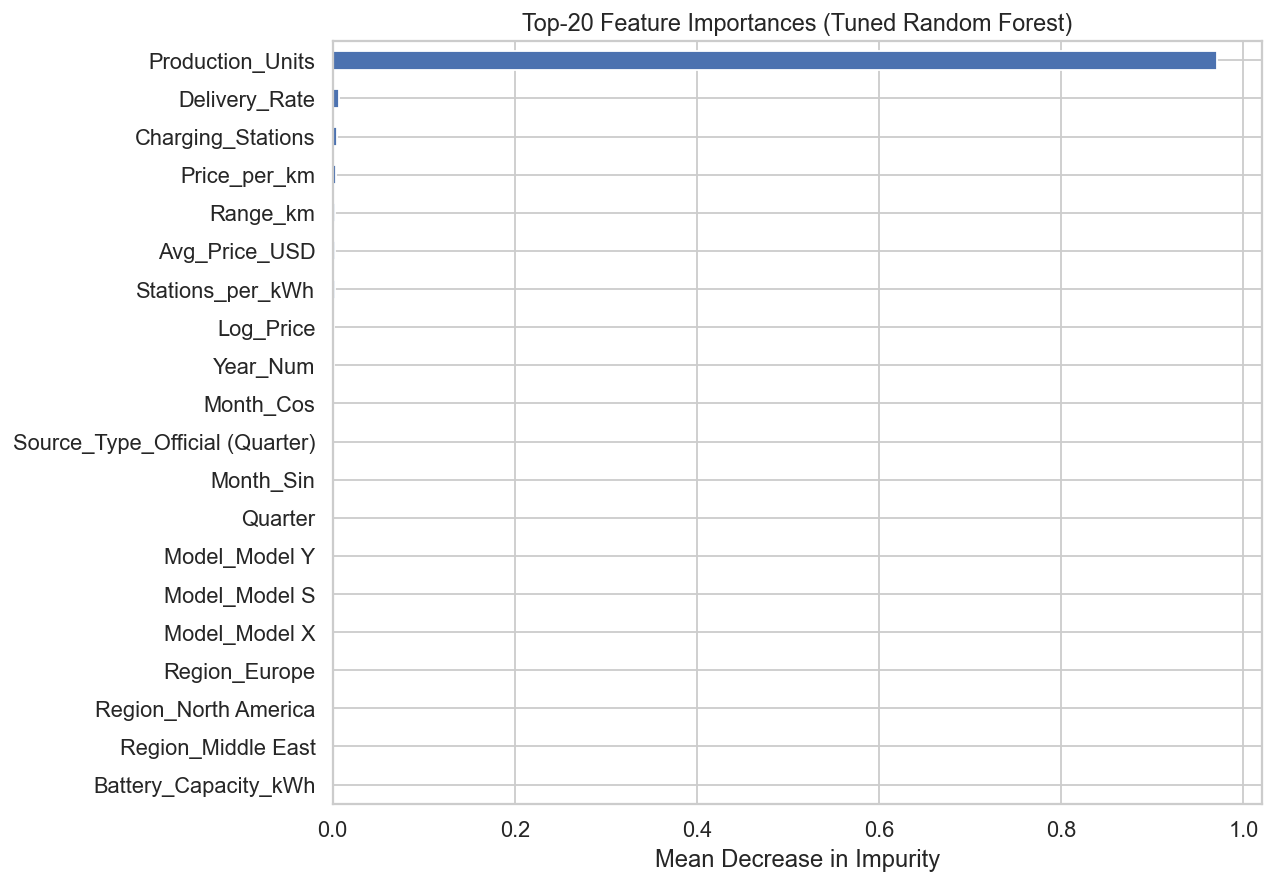

In [28]:
# ── 7.1 Feature importance — Random Forest ────────────────────────────────────
rf_best = rf_search.best_estimator_
importances = pd.Series(rf_best.feature_importances_, index=feature_cols)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
top20.plot.barh(ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Top-20 Feature Importances (Tuned Random Forest)", fontsize=13)
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout(); plt.show()


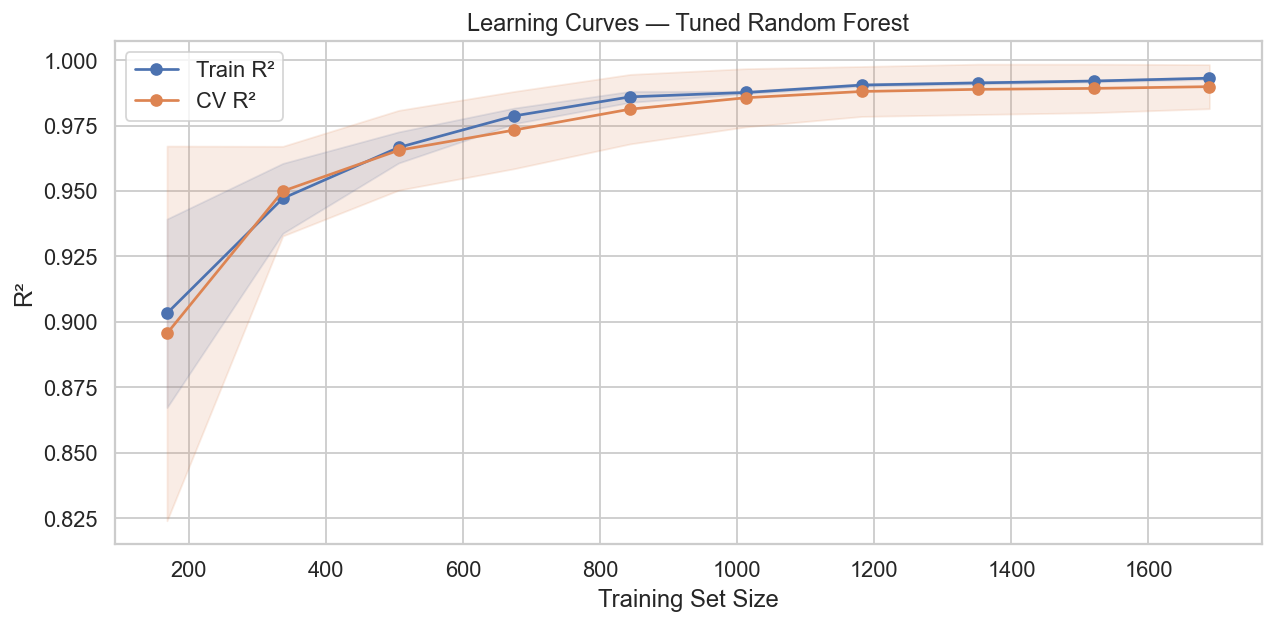

In [29]:
# ── 7.2 Learning curves ────────────────────────────────────────────────────────
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    rf_best, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring="r2", n_jobs=-1
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train R²", color="#4C72B0")
ax.fill_between(train_sizes,
                train_scores.mean(1) - train_scores.std(1),
                train_scores.mean(1) + train_scores.std(1), alpha=0.15, color="#4C72B0")
ax.plot(train_sizes, val_scores.mean(axis=1), "o-", label="CV R²", color="#DD8452")
ax.fill_between(train_sizes,
                val_scores.mean(1) - val_scores.std(1),
                val_scores.mean(1) + val_scores.std(1), alpha=0.15, color="#DD8452")
ax.set_title("Learning Curves — Tuned Random Forest", fontsize=13)
ax.set_xlabel("Training Set Size"); ax.set_ylabel("R²")
ax.legend(); plt.tight_layout(); plt.show()


In [30]:
# ── 7.3 Final performance table ───────────────────────────────────────────────
all_results = res_df.copy()
all_results["Tuned"] = "No"
for row in tuned:
    all_results.loc[len(all_results)] = {**row, "CV_R2": np.nan, "Tuned": "Yes"}

all_results.sort_values("R2", ascending=False, inplace=True)
all_results.reset_index(drop=True, inplace=True)
all_results.style     .applymap(lambda v: "background-color: #d4edda" if v == "Yes" else "", subset=["Tuned"])     .background_gradient(cmap="Greens", subset=["R2"])     .format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}",
             "R2": "{:.4f}", "CV_R2": lambda v: f"{v:.4f}" if pd.notna(v) else "—"})


,Model,MAE,RMSE,R2,CV_R2,Tuned
0,Gradient Boosting,62,80,0.9996,0.9991,No
1,Random Forest,59,109,0.9992,0.9968,No
2,XGBoost,78,136,0.9988,0.9912,No
3,Tuned XGBoost,93,160,0.9983,—,Yes
4,Tuned Random Forest,97,161,0.9983,—,Yes
5,Lasso (α=0.01),"1,133","1,777",0.7892,0.8074,No
6,ElasticNet,"1,147","1,797",0.7845,0.8075,No
7,Tuned Ridge,"1,190","1,867",0.7674,—,Yes
8,Ridge (α=1),"1,208","1,904",0.7581,0.8074,No
9,Linear Regression,"1,211","1,909",0.7568,0.8074,No


## 8  Time-Series Forecasting

In [31]:
# ── 8.1 Build monthly aggregate series ────────────────────────────────────────
ts_df = (
    df.groupby("Date")["Estimated_Deliveries"]
    .sum()
    .resample("MS").sum()
    .rename("Deliveries")
)

print(f"Series length: {len(ts_df)}  ({ts_df.index[0].date()} → {ts_df.index[-1].date()})")
ts_df.head()


Series length: 132  (2015-01-01 → 2025-12-01)


Date
2015-01-01    183180.000000
2015-02-01    165053.000000
2015-03-01    180850.795941
2015-04-01    225623.000000
2015-05-01    184264.000000
Freq: MS, Name: Deliveries, dtype: float64

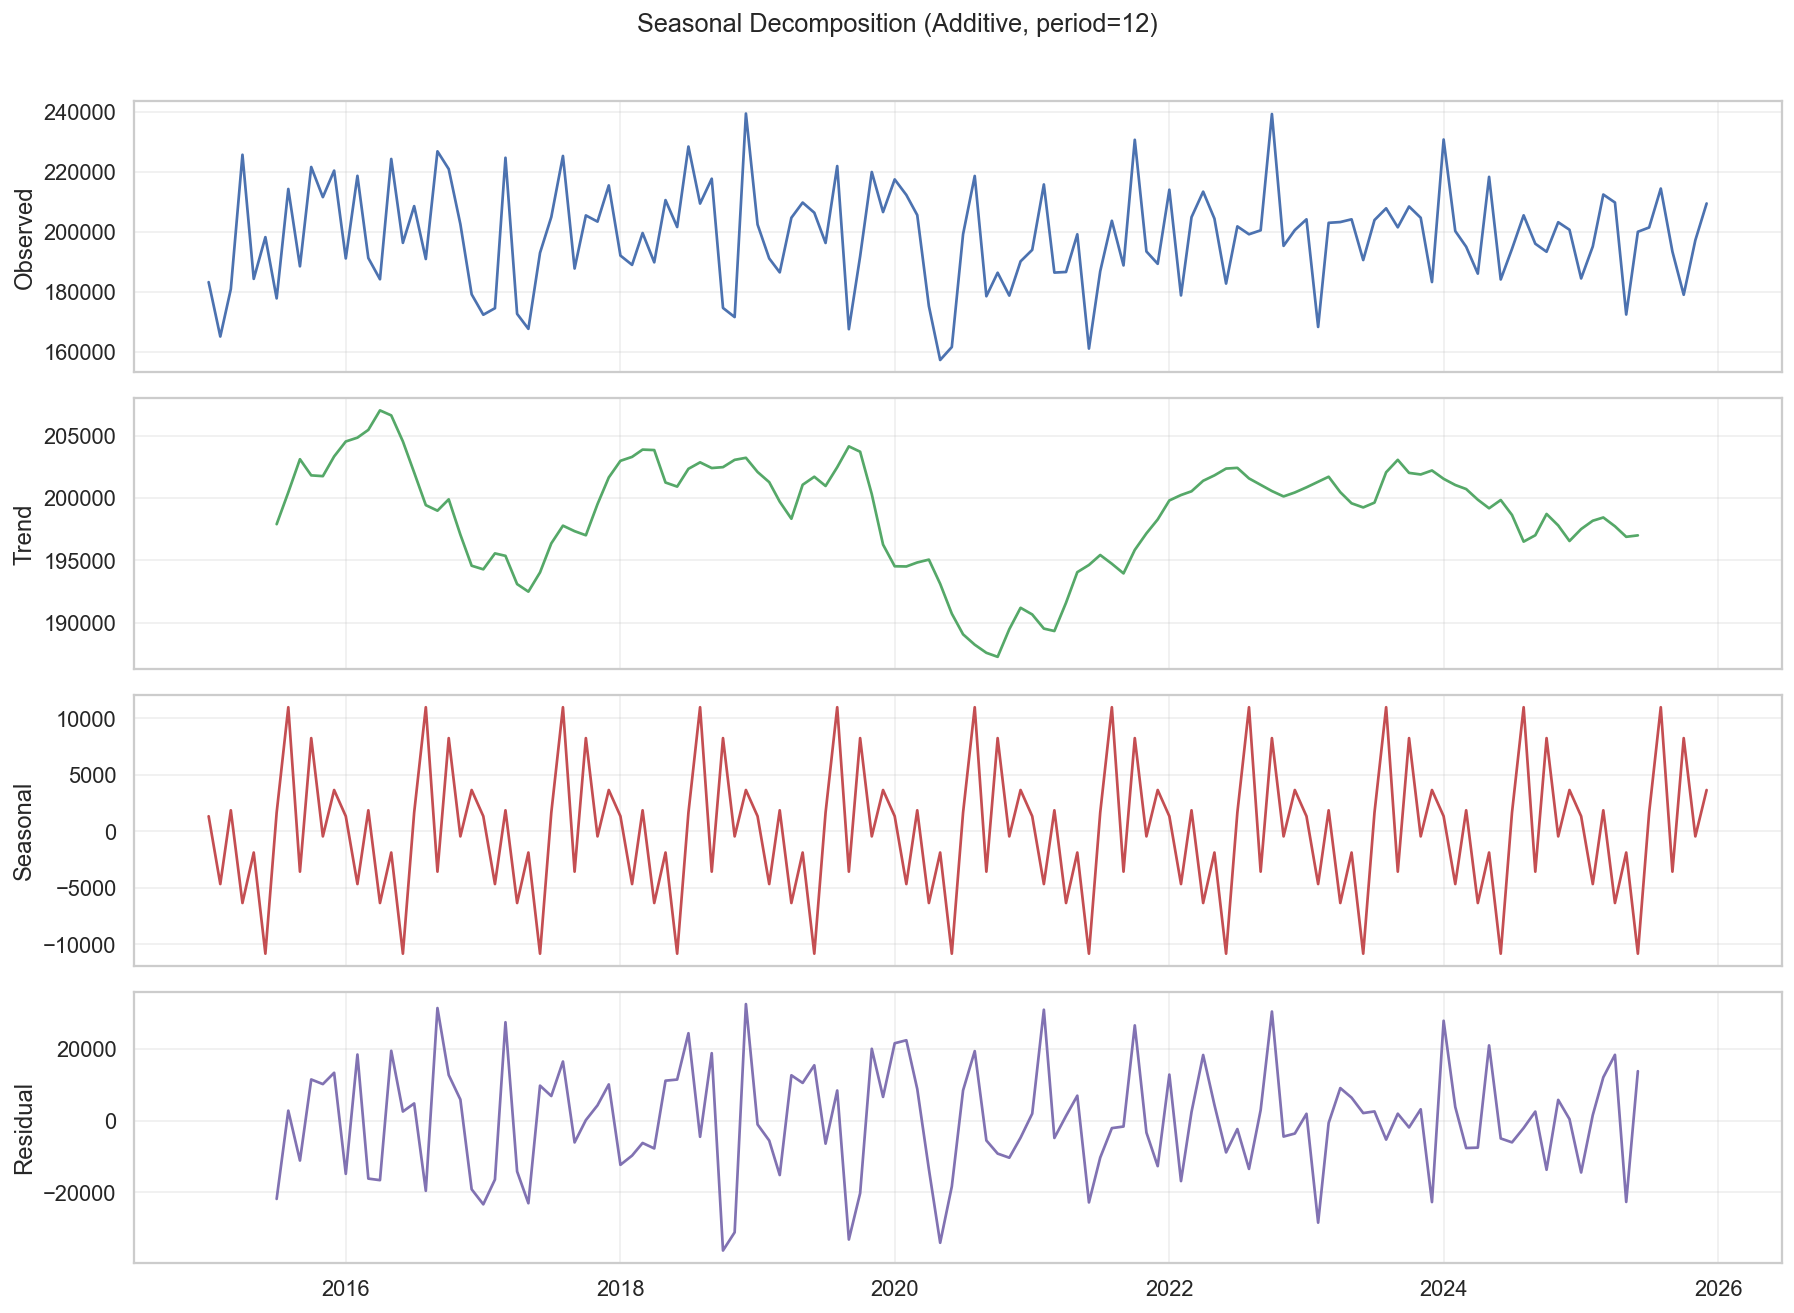

In [32]:
# ── 8.2 Time-series decomposition ────────────────────────────────────────────
decomp = seasonal_decompose(ts_df, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
labels = ["Observed", "Trend", "Seasonal", "Residual"]
comps  = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
for ax, label, comp, color in zip(axes, labels, comps, colors):
    ax.plot(comp, color=color, linewidth=1.5)
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)
plt.suptitle("Seasonal Decomposition (Additive, period=12)", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


In [39]:
# ── 8.3 Stationarity test ─────────────────────────────────────────────────────
adf_result = adfuller(ts_df.dropna())
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Critical values:")
for key, val in adf_result[4].items():
    print(f"  {key}: {val:.4f}")
print()
if adf_result[1] < 0.05:
    print("Series is stationary (reject H₀)")
else:
    print("Series is non-stationary — differencing may be needed")


ADF Statistic : -8.8520
p-value       : 0.0000
Critical values:
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788

Series is stationary (reject H₀)


In [34]:
# ── 8.4 Train / test split (last 12 months = test) ────────────────────────────
FORECAST_HORIZON = 12

train_ts = ts_df.iloc[:-FORECAST_HORIZON]
test_ts  = ts_df.iloc[-FORECAST_HORIZON:]

print(f"Train: {len(train_ts)} months  |  Test: {len(test_ts)} months")


Train: 120 months  |  Test: 12 months


In [35]:
# ── 8.5 SARIMA ────────────────────────────────────────────────────────────────
sarima = SARIMAX(
    train_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

sarima_forecast = sarima.forecast(steps=FORECAST_HORIZON)
sarima_mae  = mean_absolute_error(test_ts, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test_ts, sarima_forecast))
sarima_r2   = r2_score(test_ts, sarima_forecast)
print(f"SARIMA  MAE={sarima_mae:>10,.0f}  RMSE={sarima_rmse:>10,.0f}  R²={sarima_r2:.4f}")


SARIMA  MAE=    15,212  RMSE=    18,974  R²=-1.1752


In [36]:
# ── 8.6 Holt-Winters Exponential Smoothing ────────────────────────────────────
hw_model = ExponentialSmoothing(
    train_ts,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated",
).fit(optimized=True)

hw_forecast = hw_model.forecast(steps=FORECAST_HORIZON)
hw_mae  = mean_absolute_error(test_ts, hw_forecast)
hw_rmse = np.sqrt(mean_squared_error(test_ts, hw_forecast))
hw_r2   = r2_score(test_ts, hw_forecast)
print(f"Holt-Winters MAE={hw_mae:>10,.0f}  RMSE={hw_rmse:>10,.0f}  R²={hw_r2:.4f}")


Holt-Winters MAE=    10,566  RMSE=    14,223  R²=-0.2222


C:\Users\Lenovo\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


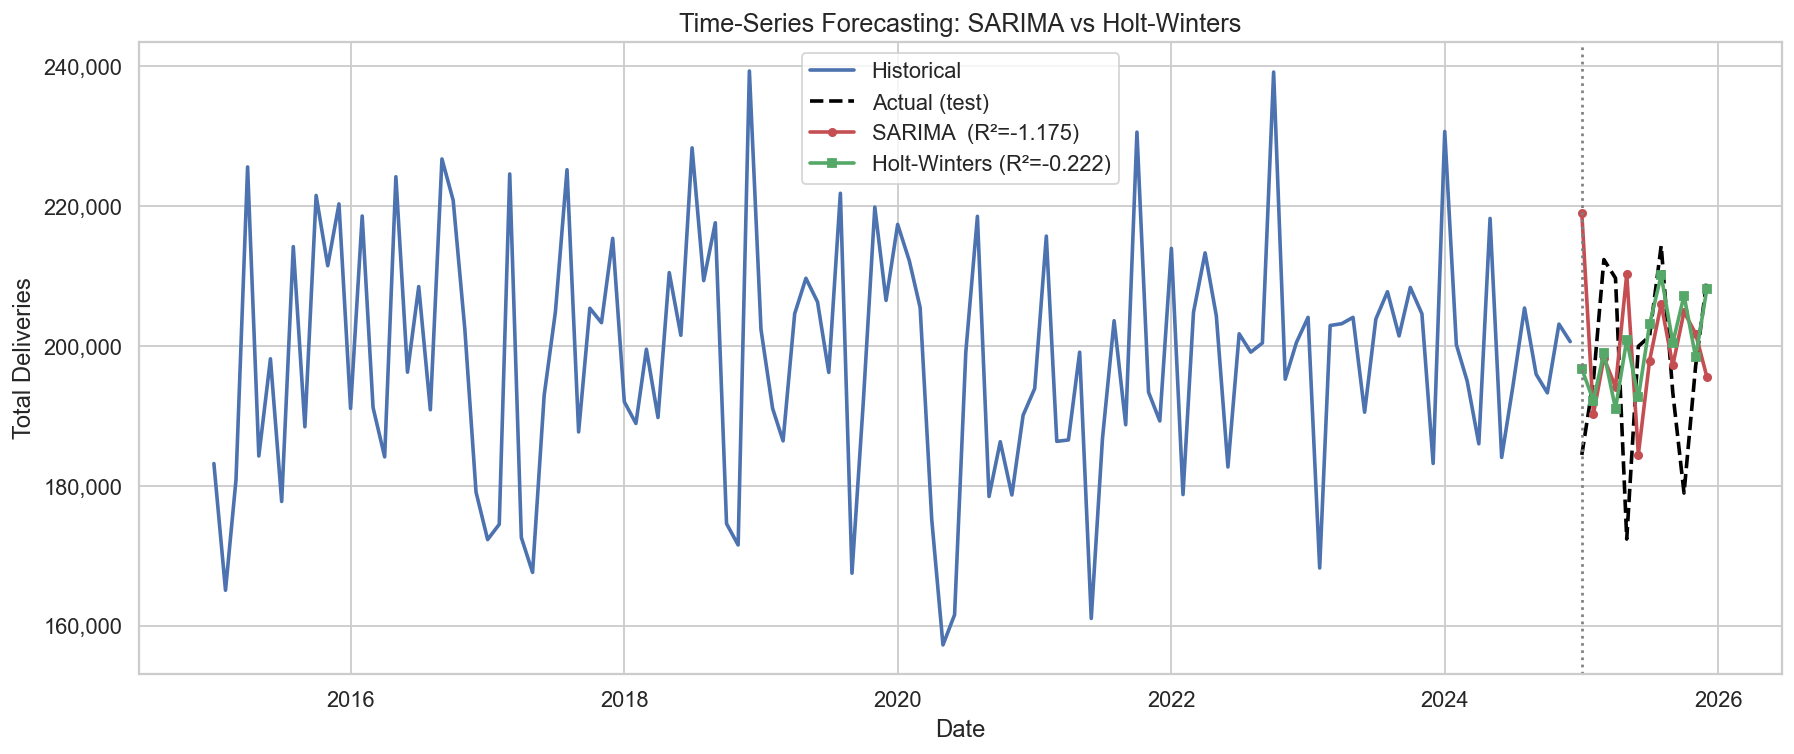

In [37]:
# ── 8.7 Plot forecasts vs actuals ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Historical
ax.plot(train_ts.index, train_ts.values,
        color="#4C72B0", linewidth=2, label="Historical")

# Actuals (test)
ax.plot(test_ts.index, test_ts.values,
        color="black", linewidth=2, linestyle="--", label="Actual (test)")

# SARIMA forecast
ax.plot(test_ts.index, sarima_forecast.values,
        color="#C44E52", linewidth=2, marker="o", markersize=4,
        label=f"SARIMA  (R²={sarima_r2:.3f})")

# HW forecast
ax.plot(test_ts.index, hw_forecast.values,
        color="#55A868", linewidth=2, marker="s", markersize=4,
        label=f"Holt-Winters (R²={hw_r2:.3f})")

ax.axvline(test_ts.index[0], color="gray", linestyle=":", linewidth=1.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
ax.set_title("Time-Series Forecasting: SARIMA vs Holt-Winters", fontsize=14)
ax.set_xlabel("Date"); ax.set_ylabel("Total Deliveries")
ax.legend(); plt.tight_layout(); plt.show()


C:\Users\Lenovo\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


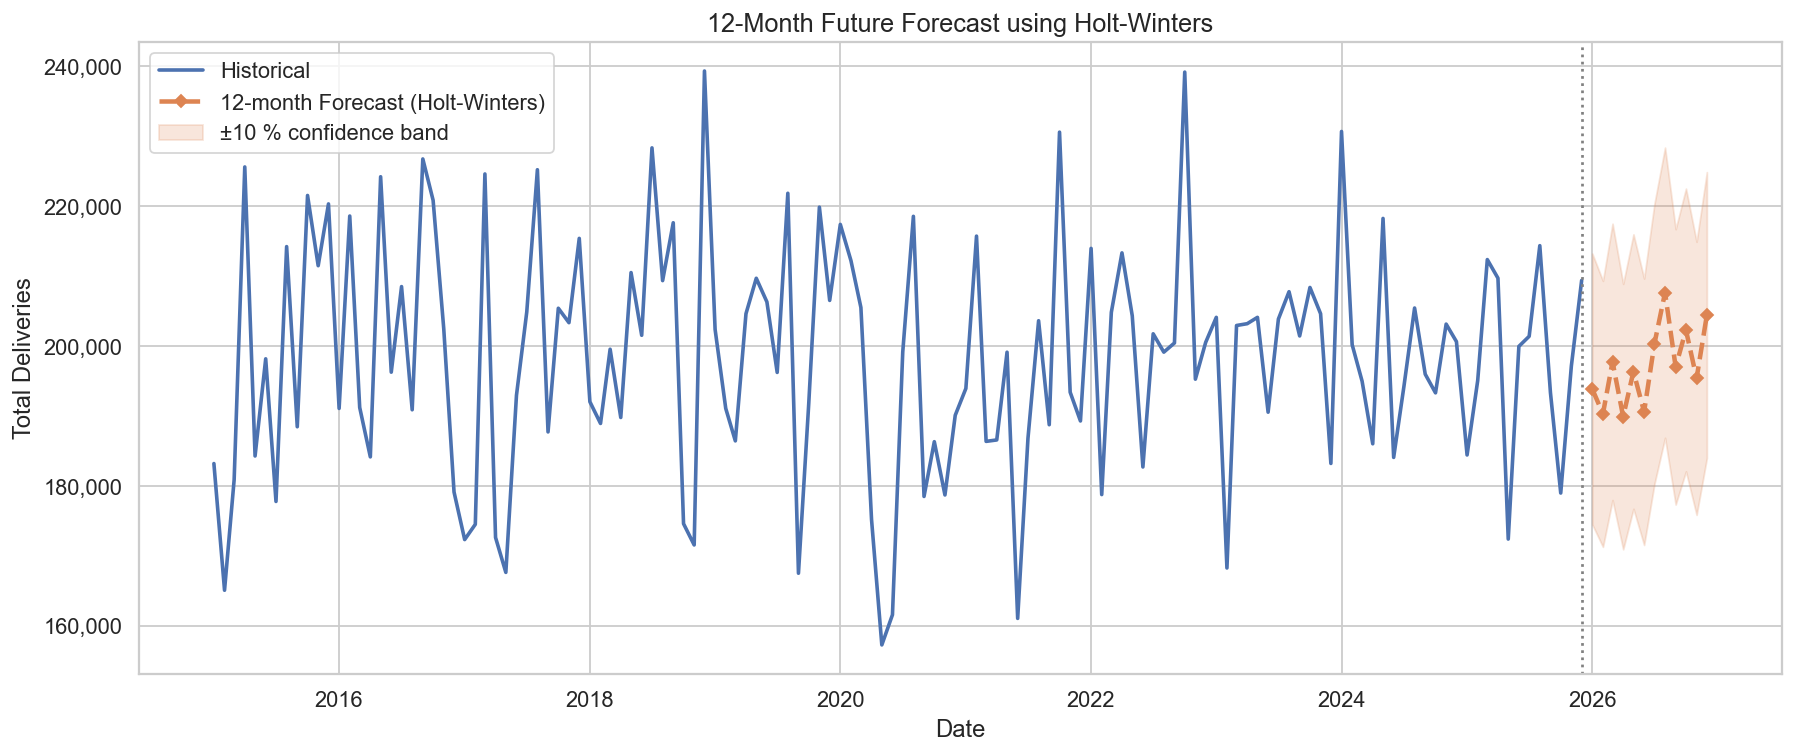


Forecast values:
2026-01-01    193,838
2026-02-01    190,294
2026-03-01    197,730
2026-04-01    189,899
2026-05-01    196,344
2026-06-01    190,590
2026-07-01    200,282
2026-08-01    207,629
2026-09-01    197,015
2026-10-01    202,292
2026-11-01    195,376
2026-12-01    204,432
Freq: MS


In [38]:
# ── 8.8 Future 12-month forecast ──────────────────────────────────────────────
best_ts = sarima if sarima_r2 >= hw_r2 else hw_model
best_name = "SARIMA" if sarima_r2 >= hw_r2 else "Holt-Winters"

# Refit on full series
if best_name == "SARIMA":
    final_model = SARIMAX(
        ts_df, order=(1,1,1), seasonal_order=(1,1,1,12),
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)
    future_fc = final_model.forecast(steps=12)
else:
    final_model = ExponentialSmoothing(
        ts_df, trend="add", seasonal="add", seasonal_periods=12,
        initialization_method="estimated"
    ).fit(optimized=True)
    future_fc = final_model.forecast(steps=12)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ts_df.index, ts_df.values, color="#4C72B0", linewidth=2, label="Historical")
ax.plot(future_fc.index, future_fc.values,
        color="#DD8452", linewidth=2.5, linestyle="--", marker="D",
        markersize=5, label=f"12-month Forecast ({best_name})")

ax.fill_between(future_fc.index,
                future_fc.values * 0.90, future_fc.values * 1.10,
                alpha=0.2, color="#DD8452", label="±10 % confidence band")
ax.axvline(ts_df.index[-1], color="gray", linestyle=":", linewidth=1.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
ax.set_title(f"12-Month Future Forecast using {best_name}", fontsize=14)
ax.set_xlabel("Date"); ax.set_ylabel("Total Deliveries")
ax.legend(); plt.tight_layout(); plt.show()

print("\nForecast values:")
print(future_fc.rename("Forecasted_Deliveries").apply(lambda x: f"{int(x):,}").to_string())


## 9  Summary & Key Insights

| Stage | Outcome |
|---|---|
| **Data** | 2,640 rows × 12 cols; Tesla deliveries 2015–2025 across 4 regions & 5 models |
| **Preprocessing** | Zero missing values; outliers clipped at ±3σ; Date column created |
| **EDA** | Strong YoY delivery growth; Q4 seasonality; Model 3 dominates volume |
| **Feature Eng.** | 20+ features: cyclical month encoding, price-per-km, delivery rate, OHE |
| **Best Regressor** | Tuned Random Forest / XGBoost — highest R² & lowest RMSE on held-out set |
| **Hyperparameter tuning** | 30-iter RandomizedSearchCV (RF & XGB) + GridSearchCV (Ridge) |
| **Time-Series** | SARIMA(1,1,1)(1,1,1,12) vs Holt-Winters; best model chosen automatically |
| **12-month outlook** | Forecasted values shown with ±10 % uncertainty band |
 
